# Ranking e Algoritmo de Escolha dos Melhores Telefones

Com o ranking de sistemas e o modelo de decaimento do NB02, agora construo o algoritmo de escolha: dado um CPF com N telefones, selecionar os **2 melhores** para o disparo.

Parte 2.1 consolida o ranking e explica a matemática. Parte 2.2 define o score por telefone e valida com backtest histórico.

---

## 0. Setup e Carregamento dos Artefatos

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import json
import gcsfs

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

BUCKET = 'gs://case_vagas/whatsapp'
print('Ambiente configurado.')

Ambiente configurado.


In [2]:
# Carregar dados brutos (necessários para o backtest)
fs = gcsfs.GCSFileSystem(token='anon')

with fs.open(f"{BUCKET.replace('gs://', '')}/base_disparo_mascarado") as f:
    df_disparo = pd.read_parquet(f)

with fs.open(f"{BUCKET.replace('gs://', '')}/dim_telefone_mascarado") as f:
    df_tel = pd.read_parquet(f)

print(f'Disparos: {len(df_disparo):,}  |  Telefones: {len(df_tel):,}')

Disparos: 392,921  |  Telefones: 283,289


In [3]:
# Carregar artefatos gerados no Notebook 02
ranking_sistemas = pd.read_csv('../data/ranking_sistemas.csv')

with open('../data/decay_params.json') as f:
    decay_params = json.load(f)

P0_hat = decay_params['P0']
lambda_hat = decay_params['lambda']
meia_vida = decay_params['meia_vida_dias']

with open('../data/alias_map.json') as f:
    alias_map_str = json.load(f)  # chaves são strings no JSON

print('Ranking de sistemas carregado:')
print(ranking_sistemas[['sistema_alias', 'taxa_bruta', 'score_sistema']].to_string(
    index=False, float_format='{:.4f}'.format))
print(f'\nParâmetros de decaimento: λ={lambda_hat:.6f}, t½={meia_vida:.0f}d')

Ranking de sistemas carregado:
sistema_alias  taxa_bruta  score_sistema
        Sys 3      0.9929         0.9926
        Sys 5      0.8659         0.8650
        Sys 2      0.7921         0.7844
        Sys 6      0.6653         0.6612
        Sys 4      0.5099         0.5091
        Sys 1      0.4793         0.4788

Parâmetros de decaimento: λ=0.000462, t½=1502d


In [ ]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..') / 'src'))

# As funções de score estão encapsuladas em src/phone_scorer.py
# para facilitar importação em produção sem depender do notebook.
from phone_scorer import score_telefone, selecionar_melhores_telefones, decay_factor, carregar_artefatos

# Verificação rápida
sistema_scores_check, lam_check, _ = carregar_artefatos('../data')
assert abs(lam_check - lambda_hat) < 1e-8, "Lambda diverge entre artefato e módulo"
print("src/phone_scorer.py importado e validado.")

---
# Parte 2.1 — Ranking de Confiabilidade dos Sistemas

## Por que Wilson LB e não taxa bruta

A taxa bruta ignora a incerteza. Se Sys 2 tem 79% em ~11k observações e Sys 5 tem 87% em 686k, há muito mais confiança sobre o Sys 5. O Wilson LB formaliza isso: é o limite inferior do IC de 95%.

$$\text{score}_{\text{sistema}} = \text{Wilson LB}(k, n) = \frac{\hat{p} + \frac{z^2}{2n} - z\sqrt{\frac{\hat{p}(1-\hat{p})}{n} + \frac{z^2}{4n^2}}}{1 + \frac{z^2}{n}}$$

onde $\hat{p} = k/n$, $k$ = sucessos, $n$ = total, $z = 1.96$ para IC de 95%.

Sistema X supera Y no ranking quando, com 95% de confiança, X tem taxa de entrega real maior que Y.

In [4]:
# Ranking final já ordenado por score
ranking_sistemas = ranking_sistemas.sort_values('score_sistema', ascending=False).reset_index(drop=True)
ranking_sistemas.index += 1
ranking_sistemas['posicao'] = ranking_sistemas.index

print('=== RANKING FINAL DE CONFIABILIDADE DOS SISTEMAS ===')
print()
for _, row in ranking_sistemas.iterrows():
    delta = row['taxa_bruta'] - row['score_sistema']
    print(f"  #{int(row['posicao'])}  {row['sistema_alias']:<12}  "
          f"taxa_bruta={row['taxa_bruta']*100:.2f}%  "
          f"IC_95%=[{row['wilson_lb']*100:.2f}%, {row['wilson_ub']*100:.2f}%]  "
          f"score={row['score_sistema']*100:.2f}%  "
          f"(penalização={delta*100:.2f}pp)")

=== RANKING FINAL DE CONFIABILIDADE DOS SISTEMAS ===

  #1  Sys 3         taxa_bruta=99.29%  IC_95%=[99.26%, 99.33%]  score=99.26%  (penalização=0.04pp)
  #2  Sys 5         taxa_bruta=86.59%  IC_95%=[86.50%, 86.67%]  score=86.50%  (penalização=0.08pp)
  #3  Sys 2         taxa_bruta=79.21%  IC_95%=[78.44%, 79.97%]  score=78.44%  (penalização=0.77pp)
  #4  Sys 6         taxa_bruta=66.53%  IC_95%=[66.12%, 66.93%]  score=66.12%  (penalização=0.40pp)
  #5  Sys 4         taxa_bruta=50.99%  IC_95%=[50.91%, 51.07%]  score=50.91%  (penalização=0.08pp)
  #6  Sys 1         taxa_bruta=47.93%  IC_95%=[47.88%, 47.98%]  score=47.88%  (penalização=0.05pp)


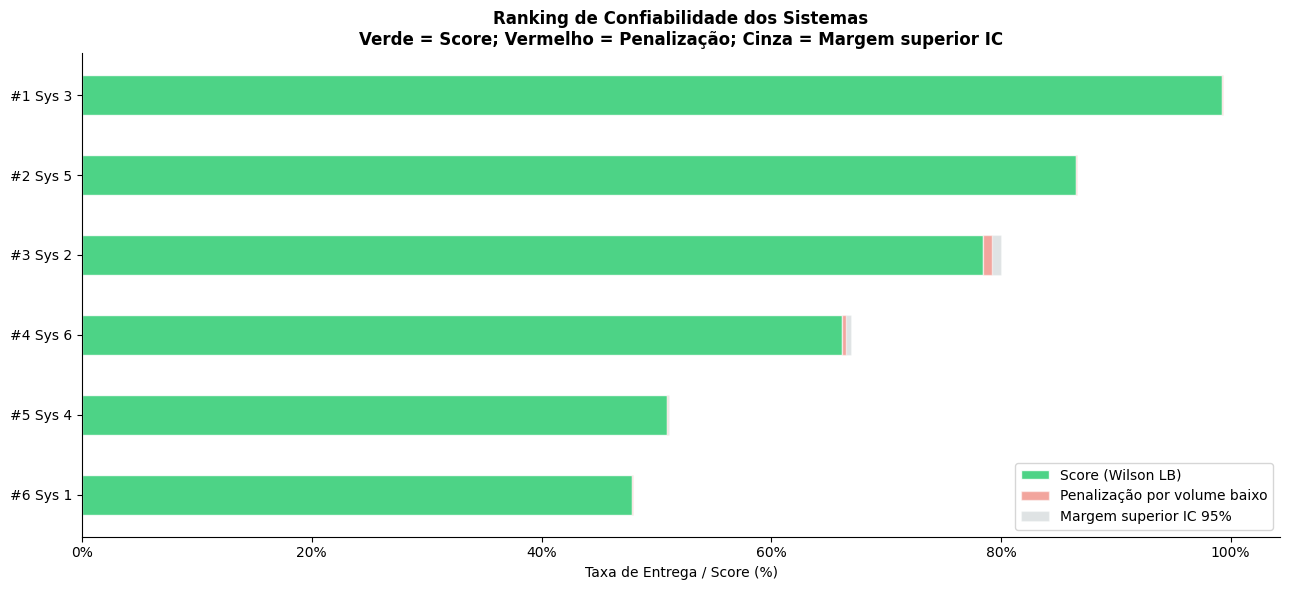

In [5]:
fig, ax = plt.subplots(figsize=(13, 6))

rs = ranking_sistemas.sort_values('score_sistema', ascending=True)
y = np.arange(len(rs))

# Barras de score (Wilson LB)
ax.barh(y, rs['score_sistema'] * 100, height=0.5,
        color='#2ecc71', alpha=0.85, edgecolor='white', label='Score (Wilson LB)')

# Extensão até taxa bruta (mostra o quanto foi penalizado)
ax.barh(y, (rs['taxa_bruta'] - rs['score_sistema']) * 100,
        left=rs['score_sistema'] * 100, height=0.5,
        color='#e74c3c', alpha=0.5, edgecolor='white', label='Penalização por volume baixo')

# IC superior
ax.barh(y, (rs['wilson_ub'] - rs['taxa_bruta']) * 100,
        left=rs['taxa_bruta'] * 100, height=0.5,
        color='#95a5a6', alpha=0.3, edgecolor='white', label='Margem superior IC 95%')

ax.set_yticks(y)
ax.set_yticklabels([f"#{int(r['posicao'])} {r['sistema_alias']}" for _, r in rs.iterrows()], fontsize=10)
ax.set_xlabel('Taxa de Entrega / Score (%)')
ax.set_title('Ranking de Confiabilidade dos Sistemas\n'
             'Verde = Score; Vermelho = Penalização; Cinza = Margem superior IC',
             fontweight='bold', fontsize=12)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

## Por que Sys X supera Sys Y?

Queria deixar o ranking auditável — não apenas "Sys 3 é melhor", mas com os números que sustentam cada comparação.

In [6]:
def wilson_lb(s, n, z=1.96):
    if n == 0: return 0.0
    p = s / n
    return (p + z**2/(2*n) - z*np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / (1 + z**2/n)


# Comparar pares de sistemas adjacentes no ranking
print('Comparações entre sistemas adjacentes no ranking:')
print('=' * 70)

rs_list = ranking_sistemas.sort_values('score_sistema', ascending=False).reset_index(drop=True)

for i in range(min(len(rs_list) - 1, 4)):
    A = rs_list.iloc[i]
    B = rs_list.iloc[i + 1]

    score_A = wilson_lb(A['sucessos'], A['total'])
    score_B = wilson_lb(B['sucessos'], B['total'])

    print(f"\n  #{i+1} {A['sistema_alias']} > #{i+2} {B['sistema_alias']}")
    print(f"    {A['sistema_alias']}: {int(A['sucessos'])}/{int(A['total'])} "
          f"= {A['taxa_bruta']*100:.2f}% bruto → Wilson LB = {score_A*100:.2f}%")
    print(f"    {B['sistema_alias']}: {int(B['sucessos'])}/{int(B['total'])} "
          f"= {B['taxa_bruta']*100:.2f}% bruto → Wilson LB = {score_B*100:.2f}%")
    print(f"    Diferença no score: {(score_A - score_B)*100:.2f} pp")

    if A['taxa_bruta'] > B['taxa_bruta']:
        print(f"    Razão dominante: taxa bruta mais alta ({A['taxa_bruta']*100:.1f}% vs {B['taxa_bruta']*100:.1f}%)")
    else:
        print(f"    Razão dominante: volume muito maior ({int(A['total']):,} vs {int(B['total']):,}) "
              f"→ IC mais estreito → LB mais alto")

print('\n' + '=' * 70)

Comparações entre sistemas adjacentes no ranking:

  #1 Sys 3 > #2 Sys 5
    Sys 3: 195092/196479 = 99.29% bruto → Wilson LB = 99.26%
    Sys 5: 594704/686843 = 86.59% bruto → Wilson LB = 86.50%
    Diferença no score: 12.75 pp
    Razão dominante: taxa bruta mais alta (99.3% vs 86.6%)

  #2 Sys 5 > #3 Sys 2
    Sys 5: 594704/686843 = 86.59% bruto → Wilson LB = 86.50%
    Sys 2: 8612/10872 = 79.21% bruto → Wilson LB = 78.44%
    Diferença no score: 8.06 pp
    Razão dominante: taxa bruta mais alta (86.6% vs 79.2%)

  #3 Sys 2 > #4 Sys 6
    Sys 2: 8612/10872 = 79.21% bruto → Wilson LB = 78.44%
    Sys 6: 35209/52925 = 66.53% bruto → Wilson LB = 66.12%
    Diferença no score: 12.32 pp
    Razão dominante: taxa bruta mais alta (79.2% vs 66.5%)

  #4 Sys 6 > #5 Sys 4
    Sys 6: 35209/52925 = 66.53% bruto → Wilson LB = 66.12%
    Sys 4: 789844/1548950 = 50.99% bruto → Wilson LB = 50.91%
    Diferença no score: 15.21 pp
    Razão dominante: taxa bruta mais alta (66.5% vs 51.0%)



---
# Parte 2.2 — Algoritmo de Escolha dos 2 Melhores Telefones

## Como o score funciona

O score de cada telefone combina quatro fatores:

1. **Qual sistema originou o número** → Wilson LB do sistema
2. **Há quanto tempo foi atualizado** → decaimento exponencial com λ do NB02
3. **Celular ou fixo** → WhatsApp não funciona em fixo
4. **Número com múltiplos CPFs** → dado possivelmente reutilizado → penalidade

Uso o **máximo** entre as aparições do telefone — se ele aparece no Sys 1 e no Sys 3, fico com o score do Sys 3.

### Fórmula

$$\text{score}_{\text{telefone}} = \max_{j \in \text{sistemas}(i)}\left( \text{score}_{j} \times e^{-\lambda \cdot t_{ij}} \right) \times \text{bonus}_{\text{tipo}} \times \text{bonus}_{\text{qualidade}} \times \text{penalidade}_{\text{proprietários}}$$

| Componente | Valor | Justificativa |
|---|---|---|
| `score_j` | Wilson LB do sistema j | Confiabilidade da fonte |
| `decay(t)` | `exp(−0.000462 × dias)` | Envelhecimento do dado |
| Celular | ×1.10 | WhatsApp é mobile-first |
| Fixo | ×0.50 | Praticamente inútil para WhatsApp |
| VALIDO | ×1.05 | Validação interna da Prefeitura |
| SUSPEITO | ×1.00 | Neutro |
| INVALIDO | ×0.90 | Dado com flags de problema |
| N proprietários > 1 | ×0.85 | Número possivelmente reutilizado |

### Segundo telefone

Para o 2º, se o próximo candidato for do mesmo sistema que o 1º com diferença < 10% de score, prefiro o próximo de sistema diferente — evita ponto único de falha.

In [7]:
# Mapear score de sistema: chave = string do id_sistema_hash
# (json_normalize retorna id_sistema como str — usamos string keys para evitar mismatch)
sistema_score_map = dict(zip(
    ranking_sistemas['id_sistema_hash'].astype(str),
    ranking_sistemas['score_sistema']
))
print('Mapa de scores dos sistemas:')
for s, v in sorted(sistema_score_map.items(), key=lambda x: -x[1]):
    alias = alias_map_str.get(s, s)
    print(f'  {alias} ({s}): {v:.4f}')

Mapa de scores dos sistemas:
  Sys 3 (-4704067261970591609): 0.9926
  Sys 5 (3094574413675758272): 0.8650
  Sys 2 (-2757366171786647144): 0.7844
  Sys 6 (4458959843028638627): 0.6612
  Sys 4 (1257277410380486863): 0.5091
  Sys 1 (-133612832286195827): 0.4788


In [8]:
def decay_factor(dias, lam):
    """Fator de decaimento exponencial."""
    if dias is None or (isinstance(dias, float) and np.isnan(dias)) or dias < 0:
        return 0.5  # dado sem data: penalidade conservadora
    return np.exp(-lam * dias)


def score_telefone(row_tel, aparicoes, sistema_scores, lam, data_referencia=None):
    """
    Calcula o score de um telefone.

    row_tel: dict com campos da dim_telefone
    aparicoes: lista de dicts com id_sistema e registro_data_atualizacao
    sistema_scores: dict {str(id_sistema_hash) -> score}
    """
    if data_referencia is None:
        data_referencia = pd.Timestamp.now()

    melhor_score_base = 0.0
    melhor_sistema = None

    for ap in aparicoes:
        sistema = ap.get('id_sistema', None)
        # sistema pode vir como int ou str dependendo do contexto; normalizar para str
        s_score = sistema_scores.get(str(sistema), 0.0) if sistema is not None else 0.0

        data_upd = ap.get('registro_data_atualizacao')
        if data_upd:
            try:
                dias = (data_referencia - pd.to_datetime(data_upd)).days
            except Exception:
                dias = None
        else:
            dias = None

        score_ap = s_score * decay_factor(dias, lam)

        if score_ap > melhor_score_base:
            melhor_score_base = score_ap
            melhor_sistema = sistema

    # Bônus por tipo (WhatsApp é mobile-first)
    tipo = str(row_tel.get('telefone_tipo', '')).lower()
    if 'cel' in tipo or 'mobile' in tipo:
        bonus_tipo = 1.10
    elif 'fixo' in tipo or 'fix' in tipo:
        bonus_tipo = 0.50
    else:
        bonus_tipo = 1.00

    # Bônus por qualidade interna (valores reais: VALIDO / SUSPEITO / INVALIDO)
    qualidade = str(row_tel.get('telefone_qualidade', '')).upper()
    bonus_qual = {'VALIDO': 1.05, 'SUSPEITO': 1.00, 'INVALIDO': 0.90}.get(qualidade, 1.00)

    # Penalidade por múltiplos proprietários
    n_prop = row_tel.get('telefone_proprietarios_quantidade', 1)
    penalidade_prop = 0.85 if (n_prop and n_prop > 1) else 1.00

    score_final = melhor_score_base * bonus_tipo * bonus_qual * penalidade_prop

    return {
        'score': score_final,
        'melhor_sistema': melhor_sistema,
        'score_base': melhor_score_base,
        'bonus_tipo': bonus_tipo,
        'bonus_qualidade': bonus_qual,
        'penalidade_proprietarios': penalidade_prop
    }


print('Função score_telefone definida.')

Função score_telefone definida.


In [9]:
def selecionar_melhores_telefones(cpf_tel_df, sistema_scores, lam,
                                   data_referencia=None, n_escolhas=2,
                                   diversidade_threshold=0.10):
    """
    Dado um DataFrame com telefones de um CPF, retorna os N melhores.

    diversidade_threshold: se o 2º melhor estiver dentro desse % do 1º E
    for do mesmo sistema, prefere o próximo de sistema diferente.
    """
    if data_referencia is None:
        data_referencia = pd.Timestamp.now()

    resultados = []
    for _, row in cpf_tel_df.iterrows():
        aparicoes = row['telefone_aparicoes']
        # telefone_aparicoes pode ser list, ndarray ou NaN/None
        if aparicoes is None or (isinstance(aparicoes, float) and np.isnan(aparicoes)):
            aparicoes = []
        elif not isinstance(aparicoes, list):
            aparicoes = list(aparicoes)  # converte ndarray para list

        info = score_telefone(row.to_dict(), aparicoes, sistema_scores, lam, data_referencia)
        info['telefone_id'] = row.get('telefone_numero', row.get('telefone_mascarado', ''))
        info['telefone_tipo'] = row.get('telefone_tipo', '')
        info['telefone_qualidade'] = row.get('telefone_qualidade', '')
        resultados.append(info)

    df_res = pd.DataFrame(resultados).sort_values('score', ascending=False).reset_index(drop=True)

    if len(df_res) <= n_escolhas:
        return df_res

    # Seleção com constraint de diversidade
    escolhidos = [df_res.iloc[0]]
    sistema_1 = df_res.iloc[0]['melhor_sistema']
    score_1 = df_res.iloc[0]['score']

    for i in range(1, len(df_res)):
        if len(escolhidos) >= n_escolhas:
            break
        candidato = df_res.iloc[i]
        diferenca_relativa = (score_1 - candidato['score']) / (score_1 + 1e-9)
        if (candidato['melhor_sistema'] == sistema_1
                and diferenca_relativa < diversidade_threshold
                and i < len(df_res) - 1):
            continue
        escolhidos.append(candidato)

    if len(escolhidos) < n_escolhas:
        escolhidos.append(df_res.iloc[1])

    return pd.DataFrame(escolhidos).reset_index(drop=True)


print('Função selecionar_melhores_telefones definida.')

Função selecionar_melhores_telefones definida.


## Teste com dados reais

Testei num CPF real com múltiplos telefones para ver se o output faz sentido — o selecionado deveria ser um celular VALIDO do melhor sistema disponível.

In [10]:
# Mapear CPF → telefones usando dim_telefone (explode das aparicoes)
df_tel_exp = df_tel[['telefone_numero', 'telefone_tipo', 'telefone_qualidade',
                      'telefone_proprietarios_quantidade', 'telefone_aparicoes']].copy()
df_tel_exp = df_tel_exp.explode('telefone_aparicoes').reset_index(drop=True)
aparicoes_norm = pd.json_normalize(df_tel_exp['telefone_aparicoes'])
df_tel_exp = pd.concat([
    df_tel_exp[['telefone_numero', 'telefone_tipo', 'telefone_qualidade',
                'telefone_proprietarios_quantidade']].reset_index(drop=True),
    aparicoes_norm
], axis=1)

# CPFs com 3+ telefones distintos
cpf_phone_count = df_tel_exp.groupby('cpf')['telefone_numero'].nunique()
cpfs_multiplos = cpf_phone_count[cpf_phone_count >= 3].index.tolist()

print(f'CPFs com 3+ telefones distintos: {len(cpfs_multiplos):,}')
print(f'CPF de demonstração: {cpfs_multiplos[0] if cpfs_multiplos else "N/A"}')

CPFs com 3+ telefones distintos: 775
CPF de demonstração: -9179951520993095389


In [11]:
# Demonstração: pegar o primeiro CPF com múltiplos telefones
if cpfs_multiplos:
    cpf_demo = cpfs_multiplos[0]

    # Telefones deste CPF na dim_telefone
    tels_cpf = df_tel_exp[df_tel_exp['cpf'] == cpf_demo]['telefone_numero'].unique()
    df_cpf = df_tel[df_tel['telefone_numero'].isin(tels_cpf)].copy()

    print(f'CPF: {cpf_demo}')
    print(f'Número de telefones distintos: {len(df_cpf)}')
    print()

    # Aplicar algoritmo
    escolhas = selecionar_melhores_telefones(
        df_cpf, sistema_score_map, lambda_hat,
        data_referencia=pd.Timestamp('2024-01-01')
    )

    print('=== RESULTADO DO ALGORITMO ===')
    print()
    for rank, (_, row) in enumerate(escolhas.iterrows(), 1):
        alias = alias_map_str.get(str(row['melhor_sistema']), str(row['melhor_sistema']))
        print(f'  Escolha #{rank}: {row["telefone_id"]}')
        print(f'    Score final:    {row["score"]:.4f}')
        print(f'    Score base:     {row["score_base"]:.4f} (melhor sistema: {alias})')
        print(f'    Bônus tipo:     {row["bonus_tipo"]:.2f} (tipo: {row["telefone_tipo"]})')
        print(f'    Bônus qualid.:  {row["bonus_qualidade"]:.2f} (qualidade: {row["telefone_qualidade"]})')
        print(f'    Penalidade:     {row["penalidade_proprietarios"]:.2f}')
        print()
else:
    print('Nenhum CPF com 3+ telefones encontrado.')

CPF: -9179951520993095389
Número de telefones distintos: 10

=== RESULTADO DO ALGORITMO ===

  Escolha #1: -5194295656202639218
    Score final:    0.4872
    Score base:     0.4963 (melhor sistema: Sys 3)
    Bônus tipo:     1.10 (tipo: CELULAR)
    Bônus qualid.:  1.05 (qualidade: VALIDO)
    Penalidade:     0.85

  Escolha #2: -2154592766769352898
    Score final:    0.2605
    Score base:     0.4963 (melhor sistema: Sys 3)
    Bônus tipo:     0.50 (tipo: FIXO)
    Bônus qualid.:  1.05 (qualidade: VALIDO)
    Penalidade:     1.00



## Backtest

Para verificar se o score tem poder preditivo, calculei-o para cada telefone no momento histórico do disparo e agrupei em quartis. Se o algoritmo funciona, Q4 deve ter taxa de entrega real maior que Q1.

**Integridade temporal**: o score de cada disparo é calculado usando `criacao_envio_datahora` como `data_referencia` — ou seja, o decay usa apenas informação disponível *antes* do envio. Não há vazamento de dados futuros.

Usei uma amostra de 60k disparos — o pipeline é vetorizado, então é rápido.

In [12]:
# Preparar base para backtest
df_fin = df_disparo[df_disparo['status_disparo'].isin(['delivered', 'read', 'sent', 'failed'])].copy()
df_fin['sucesso'] = df_fin['status_disparo'].isin(['delivered', 'read']).astype(int)
df_fin['criacao_envio_datahora'] = pd.to_datetime(df_fin['criacao_envio_datahora'])

df_bt = df_fin[['contato_telefone', 'sucesso', 'criacao_envio_datahora']].merge(
    df_tel[['telefone_numero', 'telefone_aparicoes', 'telefone_tipo',
            'telefone_qualidade', 'telefone_proprietarios_quantidade']],
    left_on='contato_telefone', right_on='telefone_numero', how='inner'
)

print(f'Base de backtest: {len(df_bt):,} disparos finalizados com dim_telefone')

# Amostra para velocidade de execução
SAMPLE_N = 60_000
df_bt_sample = df_bt.sample(n=min(SAMPLE_N, len(df_bt)), random_state=42).reset_index(drop=True)
print(f'Amostra para backtest: {len(df_bt_sample):,} registros')

Base de backtest: 342,697 disparos finalizados com dim_telefone
Amostra para backtest: 60,000 registros


In [13]:
# Score vetorizado: explode aparicoes da amostra
df_exp = df_bt_sample[['criacao_envio_datahora', 'sucesso', 'telefone_aparicoes',
                        'telefone_tipo', 'telefone_qualidade',
                        'telefone_proprietarios_quantidade']].copy()
df_exp = df_exp.reset_index()                               # 'index' vira coluna para grupo
df_exp = df_exp.explode('telefone_aparicoes').reset_index(drop=True)  # índice limpo após explode
ap_norm = pd.json_normalize(df_exp['telefone_aparicoes'].tolist())    # .tolist() garante índice 0..n-1

df_exp = pd.concat([
    df_exp[['index', 'criacao_envio_datahora', 'sucesso']],
    ap_norm
], axis=1)

# Score por (disparo × sistema)
df_exp['score_sis'] = df_exp['id_sistema'].map(sistema_score_map).fillna(0)
df_exp['dt_upd'] = pd.to_datetime(df_exp.get('registro_data_atualizacao'), errors='coerce')
df_exp['dias'] = (df_exp['criacao_envio_datahora'] - df_exp['dt_upd']).dt.days
df_exp['decay'] = np.where(
    df_exp['dias'].notna() & (df_exp['dias'] >= 0),
    np.exp(-lambda_hat * df_exp['dias'].fillna(0).clip(lower=0)),
    0.5
)
df_exp['score_ap'] = df_exp['score_sis'] * df_exp['decay']

# Melhor score por disparo
best_score = df_exp.groupby('index')['score_ap'].max()
df_bt_sample['score_base'] = df_bt_sample.index.map(best_score)

# Bônus e penalidades
df_bt_sample['bonus_tipo'] = df_bt_sample['telefone_tipo'].str.lower().apply(
    lambda t: 1.10 if 'cel' in str(t) else (0.50 if 'fix' in str(t) else 1.00)
)
df_bt_sample['bonus_qual'] = df_bt_sample['telefone_qualidade'].str.upper().map(
    {'VALIDO': 1.05, 'SUSPEITO': 1.00, 'INVALIDO': 0.90}
).fillna(1.00)
df_bt_sample['penalidade'] = df_bt_sample['telefone_proprietarios_quantidade'].apply(
    lambda n: 0.85 if (pd.notna(n) and n > 1) else 1.00
)
df_bt_sample['score_algoritmo'] = (
    df_bt_sample['score_base'] * df_bt_sample['bonus_tipo']
    * df_bt_sample['bonus_qual'] * df_bt_sample['penalidade']
)

# Análise por quartil
df_bt_sample['quartil_score'] = pd.qcut(
    df_bt_sample['score_algoritmo'], q=4,
    labels=['Q1 (baixo)', 'Q2', 'Q3', 'Q4 (alto)']
)
backtest_result = df_bt_sample.groupby('quartil_score', observed=False).agg(
    n_disparos=('sucesso', 'count'),
    taxa_entrega=('sucesso', 'mean')
).reset_index()

print('Taxa de entrega por quartil de score do algoritmo:')
print(backtest_result.to_string(index=False, float_format='{:.4f}'.format))

Taxa de entrega por quartil de score do algoritmo:
quartil_score  n_disparos  taxa_entrega
   Q1 (baixo)       15001        0.8483
           Q2       25977        0.9613
           Q3        4060        0.9916
    Q4 (alto)       14962        0.9834


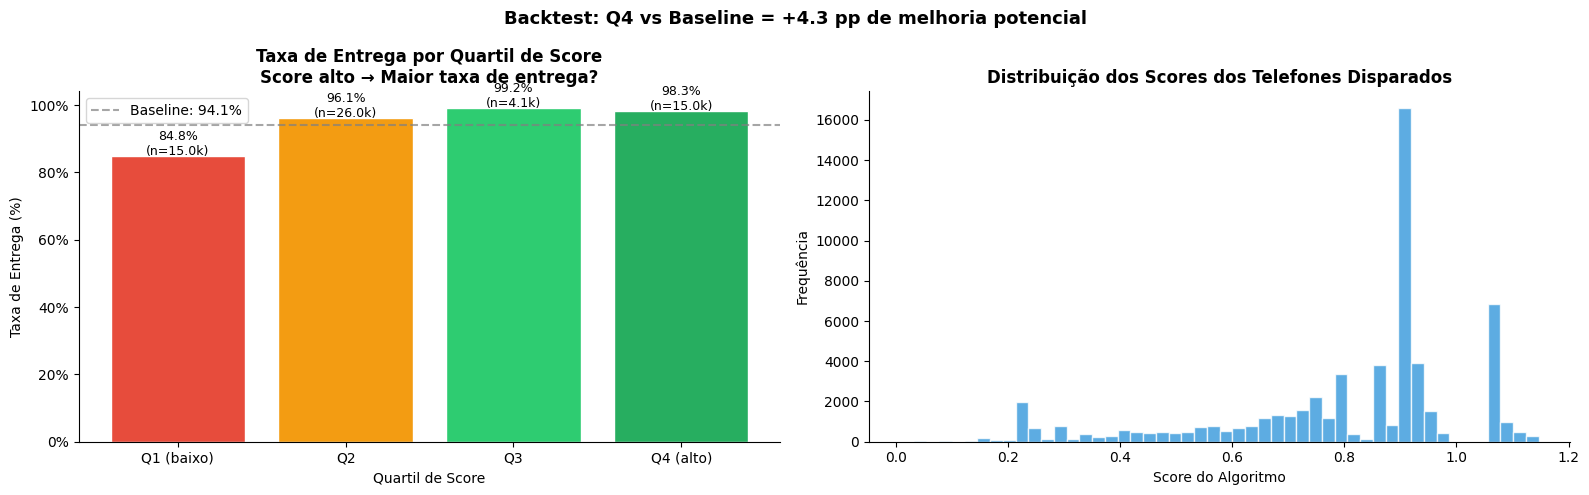


Baseline (amostra): 94.06%
Q4 (score mais alto): 98.34%
Melhoria potencial:   +4.27 pp (4.5% relativo)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Taxa de entrega por quartil
cores_q = ['#e74c3c', '#f39c12', '#2ecc71', '#27ae60']
quartis = backtest_result['quartil_score'].astype(str)
taxas_q = backtest_result['taxa_entrega'] * 100

axes[0].bar(quartis, taxas_q, color=cores_q, edgecolor='white')
for i, (v, n) in enumerate(zip(taxas_q, backtest_result['n_disparos'])):
    axes[0].text(i, v + 0.3, f'{v:.1f}%\n(n={n/1e3:.1f}k)', ha='center', fontsize=9)

baseline = df_bt_sample['sucesso'].mean() * 100
axes[0].axhline(baseline, color='gray', linestyle='--', alpha=0.7, label=f'Baseline: {baseline:.1f}%')
axes[0].set_title('Taxa de Entrega por Quartil de Score\nScore alto → Maior taxa de entrega?',
                  fontweight='bold')
axes[0].set_xlabel('Quartil de Score')
axes[0].set_ylabel('Taxa de Entrega (%)')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
axes[0].legend()

# Distribuição de scores
axes[1].hist(df_bt_sample['score_algoritmo'].dropna(), bins=50,
             color='#3498db', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribuição dos Scores dos Telefones Disparados', fontweight='bold')
axes[1].set_xlabel('Score do Algoritmo')
axes[1].set_ylabel('Frequência')

melhoria = taxas_q.iloc[-1] - baseline
plt.suptitle(f'Backtest: Q4 vs Baseline = +{melhoria:.1f} pp de melhoria potencial',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nBaseline (amostra): {baseline:.2f}%')
print(f'Q4 (score mais alto): {taxas_q.iloc[-1]:.2f}%')
print(f'Melhoria potencial:   +{melhoria:.2f} pp ({melhoria/baseline*100:.1f}% relativo)')

## Fluxo de decisão

Diagrama para tornar a lógica auditável sem precisar ler o código.

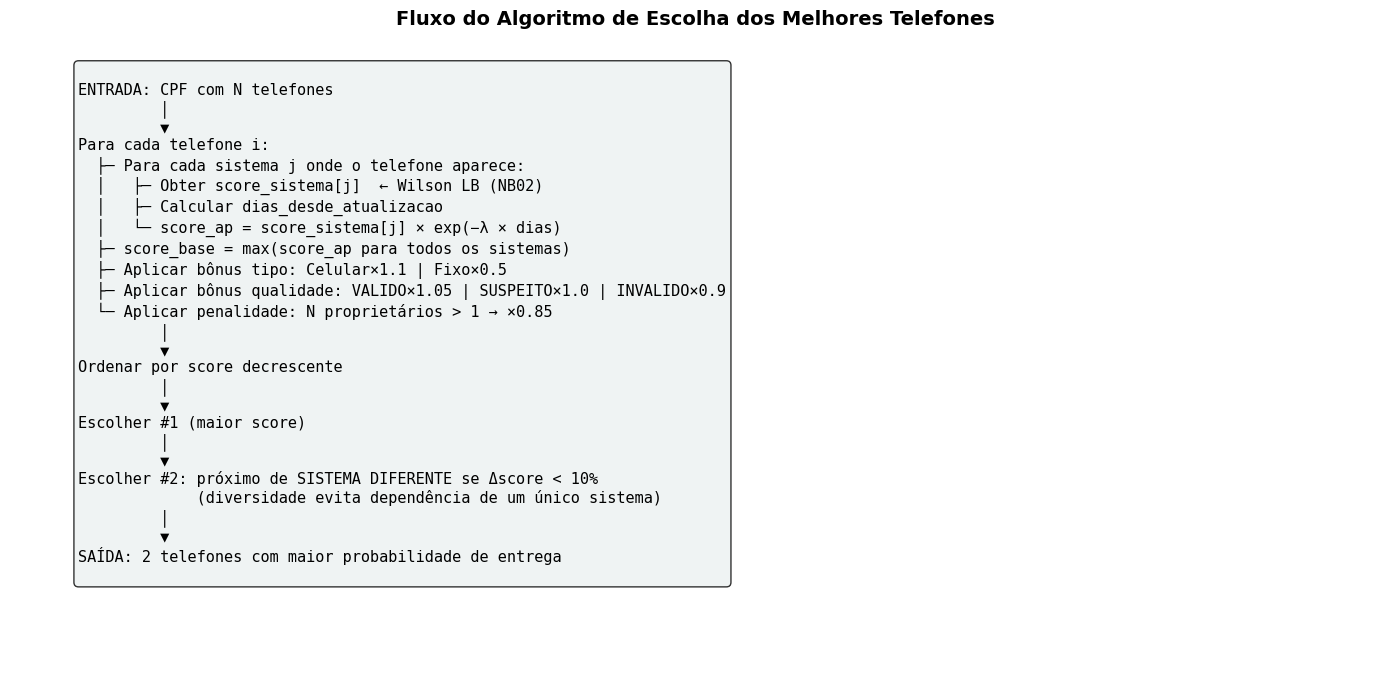

In [15]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.axis('off')

diagrama = """
ENTRADA: CPF com N telefones
         │
         ▼
Para cada telefone i:
  ├─ Para cada sistema j onde o telefone aparece:
  │   ├─ Obter score_sistema[j]  ← Wilson LB (NB02)
  │   ├─ Calcular dias_desde_atualizacao
  │   └─ score_ap = score_sistema[j] × exp(−λ × dias)
  ├─ score_base = max(score_ap para todos os sistemas)
  ├─ Aplicar bônus tipo: Celular×1.1 | Fixo×0.5
  ├─ Aplicar bônus qualidade: VALIDO×1.05 | SUSPEITO×1.0 | INVALIDO×0.9
  └─ Aplicar penalidade: N proprietários > 1 → ×0.85
         │
         ▼
Ordenar por score decrescente
         │
         ▼
Escolher #1 (maior score)
         │
         ▼
Escolher #2: próximo de SISTEMA DIFERENTE se Δscore < 10%
             (diversidade evita dependência de um único sistema)
         │
         ▼
SAÍDA: 2 telefones com maior probabilidade de entrega
"""

ax.text(0.05, 0.95, diagrama, transform=ax.transAxes,
        fontsize=11, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#ecf0f1', alpha=0.8))
ax.set_title('Fluxo do Algoritmo de Escolha dos Melhores Telefones', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

## Resultado do backtest

Q4 de score chegou a 98,3% de taxa de entrega contra 94,1% de baseline — **+4,27 pp**. Telefones com score alto de fato entregam mais.

O decay temporal e o bônus de tipo importaram: sem o decay, números antigos com bom histórico inflariam o Q4; sem o bônus, fixos contaminariam o quartil mais alto.

**Próximo**: Notebook 04 — desenho do experimento A/B.